<a href="https://colab.research.google.com/github/LeviJunior21/CienciaDadosDescritiva/blob/main/Lab_Regress%C3%A3o_Linear_para_Previs%C3%A3o_de_CRA_LeviJunior_121210472.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ISLP

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
import seaborn as sns

# Histórico dos estudantes que concluiram o curso

## Matrícula dos Estudantes que concluiram o curso

In [ ]:
import requests
import json
import threading

periodo_de_evasao_de = "2004.1"
periodo_de_evasao_ate = "2024.1"

url_matriculas_computacao = f'https://eureca.sti.ufcg.edu.br/das/v2/estudantes?periodo-de-evasao-de={periodo_de_evasao_de}&periodo-de-evasao-ate={periodo_de_evasao_ate}&curriculo-ate=2023&situacao-do-estudante=EGRESSOS&campus=1&curso=14102100'

response = requests.get(url_matriculas_computacao)
response_json = json.loads(response.text)

matriculas = [matricula["matricula_do_estudante"] for matricula in response_json]

## Histórico dos estudantes que concluiram o curso

In [ ]:
historicos = []

"""
    Busca os dados históricos de um estudante egresso (que concluiu) do curso.

    Esta função recebe a matrícula de um estudante e retorna os dados históricos das disciplinas relacionados ao seu curso, como as disciplinas cursadas, notas e o seu CRA.

    Parameters:
        matricula (str): O número de matrícula do estudante.

    Returns:
        dict: Um dicionário contendo os dados do histórico do estudante.
              Pode incluir campos como 'disciplinas', 'notas', e CRA'.

    Raises:
        ValueError: Se a matrícula fornecida for inválida ou não encontrada.
"""
def fetch_historico(matricula):
    url_historico_estudante_computacao = f'https://eureca.sti.ufcg.edu.br/das/v2/estudantes/historico/estudante-anonimizado?estudante={matricula}'

    response_historico = requests.get(url_historico_estudante_computacao)

    if (response_historico.status_code == 200):
        historico = json.loads(response_historico.text)
        cra = f'{(historico["notas_acumuladas"]/historico["creditos_do_cra"]):.2f}'
        historicos.append({
            "matricula": historico['matricula_do_estudante'],
            "historico": historico['historico_de_matriculas'],
            "cra": cra
        })

threads = []
for matricula in matriculas:
  thread = threading.Thread(target=fetch_historico, args=(matricula,))
  threads.append(thread)
  thread.start()

for thread in threads:
  thread.join()

## Lista de disciplinas interessadas

In [ ]:
disciplinas_primeiro_periodo = [
    'LABORATÓRIO DE PROGRAMAÇÃO I',
    'PROGRAMAÇÃO I',
    'INTRODUÇÃO À COMPUTAÇÃO',
    'FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I',
]

disciplinas_segundo_periodo = [
    'PROGRAMAÇÃO II',
    'LABORATÓRIO DE PROGRAMAÇÃO II',
    'CALCULO DIFERENCIAL E INTEGRAL I',
    'FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II',
]

disciplinas_terceiro_periodo = [
    'TEORIA DOS GRAFOS',
    'CALCULO DIFERENCIAL E INTEGRAL II',
    'ÁLGEBRA LINEAR I'
]

disciplinas_desejadas = disciplinas_primeiro_periodo + disciplinas_segundo_periodo + disciplinas_terceiro_periodo

## Filtro nas disciplinas interessadas

In [ ]:
historico_interessado = []

def filtrar_disciplinas(historico, disciplinas_desejadas):
    """
    Filtra as disciplinas do histórico que estão nas disciplinas desejadas
    e possuem média final não nula.
    """
    return [{
        'nome_da_disciplina': disciplina['nome_da_disciplina'],
        'media_final': disciplina['media_final']
    } for disciplina in historico['historico']
    if disciplina['nome_da_disciplina'] in disciplinas_desejadas and
    disciplina['media_final'] is not None]

def agrupar_disciplinas(disciplinas_filtradas):
    """
    Agrupa as disciplinas filtradas, mantendo apenas a disciplina com a maior média final.
    """
    disciplinas_agrupadas = {}
    for disciplina in disciplinas_filtradas:
        nome = disciplina['nome_da_disciplina']
        if nome in disciplinas_agrupadas:
            disciplinas_agrupadas[nome] = max(
                disciplinas_agrupadas[nome], disciplina, key=lambda x: x['media_final']
            )
        else:
            disciplinas_agrupadas[nome] = disciplina
    return disciplinas_agrupadas

def verificar_historico_completo(historico, disciplinas_desejadas, disciplinas_agrupadas):
    """
    Verifica se todas as disciplinas desejadas estão presentes no histórico agrupado e se todas as médias finais são maiores que 0.
    """
    result = [{'nome_da_disciplina': nome, 'media_final': data['media_final']} for nome, data in disciplinas_agrupadas.items()]
    disciplinas_resultado = {item['nome_da_disciplina'] for item in result}

    return (
        all(disciplina in disciplinas_resultado for disciplina in disciplinas_desejadas) and all(item['media_final'] > 0 for item in result), result
    )

def processar_historico(historico, disciplinas_desejadas):
    """
    Processa o histórico de um estudante, filtrando disciplinas,
    agrupando por menor média e verificando a completude de disciplinas desejadas.
    """
    disciplinas_filtradas = filtrar_disciplinas(historico, disciplinas_desejadas)
    disciplinas_agrupadas = agrupar_disciplinas(disciplinas_filtradas)
    completo, result = verificar_historico_completo(historico, disciplinas_desejadas, disciplinas_agrupadas)

    if completo:
        historico_interessado.append({
            'matricula': historico['matricula'],
            'matriculas': result,
            'cra': historico['cra']
        })

threads = []
for historico in historicos:
    thread = threading.Thread(target=processar_historico, args=(historico, disciplinas_desejadas))
    threads.append(thread)
    thread.start()

for thread in threads:
    thread.join()

## Criando o CSV das disciplinas com seus respectivos alunos e notas por disciplina

In [ ]:
import csv

with open('historicos.csv', mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)

    header = ['Matrícula', 'CRA'] + disciplinas_desejadas
    writer.writerow(header)

    for estudante in historico_interessado:
        matricula = estudante['matricula']
        cra = estudante['cra']
        notas = {disciplina['nome_da_disciplina']: disciplina['media_final'] for disciplina in estudante['matriculas']}

        row = [matricula, cra] + [notas.get(disciplina, 'N/A') for disciplina in disciplinas_desejadas]
        writer.writerow(row)

# Importando dados do CSV

In [ ]:
download_url = "./historicos.csv"

try:
    df = pd.read_csv(download_url)
    print("Dados carregados com sucesso!")
except Exception as e:
    print(f"Erro ao carregar os dados: {e}")

df.head()

Dados carregados com sucesso!


,Matrícula,CRA,LABORATÓRIO DE PROGRAMAÇÃO I,PROGRAMAÇÃO I,INTRODUÇÃO À COMPUTAÇÃO,FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I,PROGRAMAÇÃO II,LABORATÓRIO DE PROGRAMAÇÃO II,CALCULO DIFERENCIAL E INTEGRAL I,FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II,TEORIA DOS GRAFOS,CALCULO DIFERENCIAL E INTEGRAL II,ÁLGEBRA LINEAR I
0,112211049,6.36,8.0,8.0,6.0,5.7,5.0,6.5,5.7,5.1,7.8,5.0,5.0
1,113112167,6.53,5.0,5.0,7.1,7.5,5.5,5.9,7.5,5.2,5.5,5.0,7.5
2,113114833,7.83,9.0,9.0,8.8,5.6,8.4,7.9,5.6,5.3,8.3,6.1,5.0
3,113211140,6.42,8.9,8.8,7.2,6.0,7.1,7.5,6.0,6.8,7.7,7.5,7.0
4,113215649,6.77,5.5,5.5,7.5,5.8,5.0,5.1,5.8,5.4,8.3,6.0,5.8


# Usando Equações Normais como Sistema de Equações Lineares para prever o CRA

In [ ]:
dados = df.values

# Recuperando notas nas disciplinas em forma de matriz.
X = np.array([[float(x) for x in linha[2:]] for linha in dados])

# Criando uma nova primeira coluna e preenchendo-a com 1s.
X = np.hstack((np.ones((X.shape[0], 1)), X))

# Recuperando uma matriz de CRA.
Y = np.array([[float(y) for y in linha[1:2]] for linha in dados])

# Fazendo a matriz transposta de notas disciplinas.
X_t = X.T

# Fazendo o quadrado de cada termo da matriz de notas nas disciplinas.
X_tX = X_t @ X

X_tY = X_t @ Y

X_tX_inv = np.linalg.inv(X_tX)
W = X_tX_inv @ X_tY

Y_pred = X @ W

novo_X = np.array([[float(x) for x in dados[0][2:]]])
novo_X = np.hstack((np.ones((novo_X.shape[0], 1)), novo_X))

# Prevendo o CRA do aluno
cra = novo_X @ W
print(f'CRA do aluno: {cra[0][0]}')

CRA do aluno: 6.428571639021439


# Gráfico comparativo de valores reais e Sistema de Equações Normais para o CRA

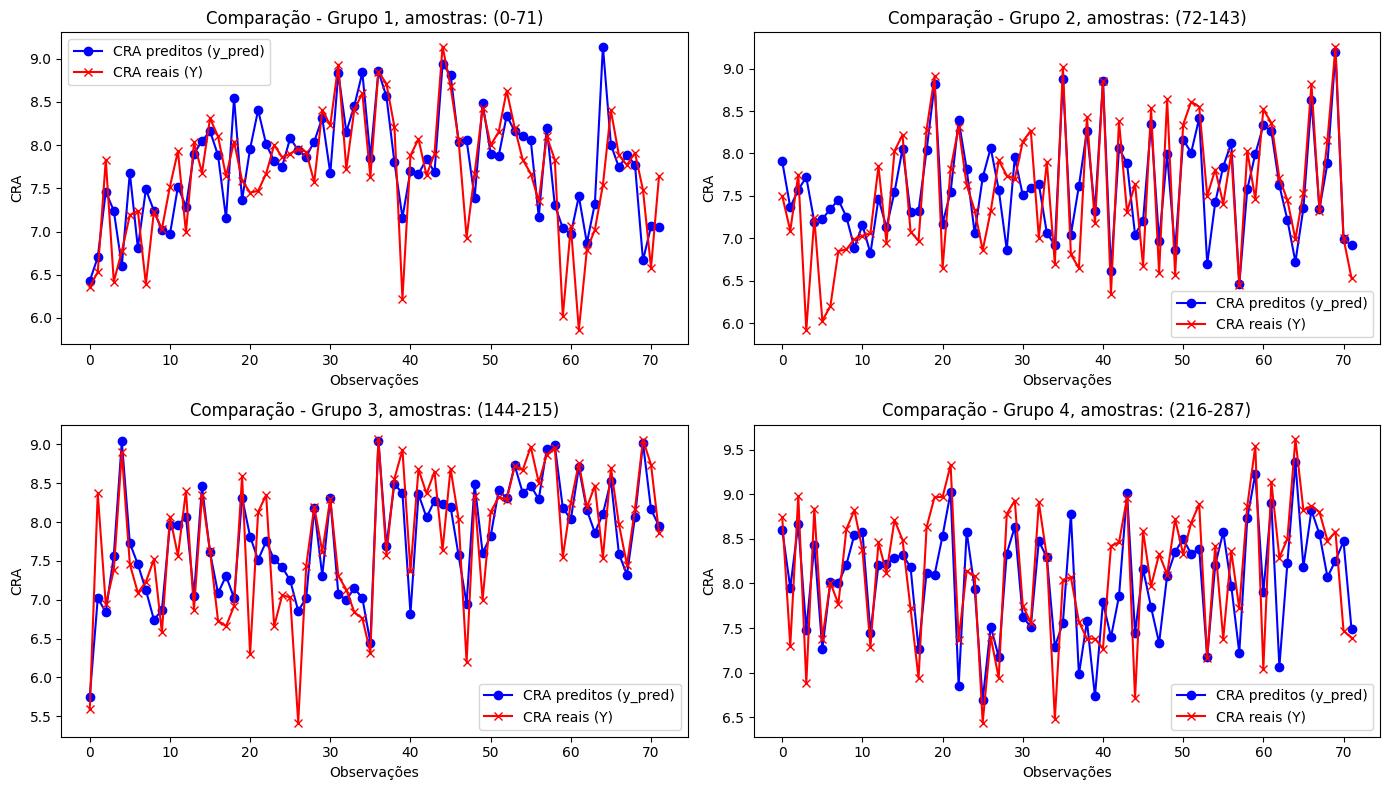

In [ ]:
import matplotlib.pyplot as plt

total_amostras = len(Y_pred)
grupo_tamanho = total_amostras // 4

def plot_graph(i, grupo_tamanho, Y_pred):
    plt.subplot(2, 2, i + 1)
    inicio = grupo_tamanho * i
    fim = grupo_tamanho * (i + 1)

    plt.plot(Y_pred[inicio:fim], label="CRA preditos (y_pred)", color="blue", marker="o")
    plt.plot(Y[inicio:fim], label="CRA reais (Y)", color="red", marker="x")
    plt.title(f"Comparação - Grupo {i + 1}, amostras: ({inicio}-{fim - 1})")
    plt.xlabel("Observações")
    plt.ylabel("CRA")
    plt.legend()

plt.figure(figsize=(14, 8))

for i in range(4):
    plot_graph(i, grupo_tamanho, Y_pred)

plt.tight_layout()
plt.show()

In [ ]:
X = pd.DataFrame({
    'intercept': np.ones(df.shape[0]),
    'LABORATÓRIO DE PROGRAMAÇÃO I': df['LABORATÓRIO DE PROGRAMAÇÃO I'],
    'PROGRAMAÇÃO I': df['PROGRAMAÇÃO I'],
    'INTRODUÇÃO À COMPUTAÇÃO': df['INTRODUÇÃO À COMPUTAÇÃO'],
    'FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I': df['FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I'],
    'PROGRAMAÇÃO II': df['PROGRAMAÇÃO II'],
    'LABORATÓRIO DE PROGRAMAÇÃO II': df['LABORATÓRIO DE PROGRAMAÇÃO II'],
    'CALCULO DIFERENCIAL E INTEGRAL I': df['CALCULO DIFERENCIAL E INTEGRAL I'],
    'FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II': df['FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II'],
    'TEORIA DOS GRAFOS': df['TEORIA DOS GRAFOS'],
    'CALCULO DIFERENCIAL E INTEGRAL II': df['CALCULO DIFERENCIAL E INTEGRAL II'],
    'ÁLGEBRA LINEAR I': df['ÁLGEBRA LINEAR I']
})

X[:4]

,intercept,LABORATÓRIO DE PROGRAMAÇÃO I,PROGRAMAÇÃO I,INTRODUÇÃO À COMPUTAÇÃO,FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I,PROGRAMAÇÃO II,LABORATÓRIO DE PROGRAMAÇÃO II,CALCULO DIFERENCIAL E INTEGRAL I,FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II,TEORIA DOS GRAFOS,CALCULO DIFERENCIAL E INTEGRAL II,ÁLGEBRA LINEAR I
0,1.0,8.0,8.0,6.0,5.7,5.0,6.5,5.7,5.1,7.8,5.0,5.0
1,1.0,5.0,5.0,7.1,7.5,5.5,5.9,7.5,5.2,5.5,5.0,7.5
2,1.0,9.0,9.0,8.8,5.6,8.4,7.9,5.6,5.3,8.3,6.1,5.0
3,1.0,8.9,8.8,7.2,6.0,7.1,7.5,6.0,6.8,7.7,7.5,7.0


In [ ]:
y = df['CRA']

model1 = sm.OLS(y, X)
results = model1.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,1.9832,0.290,6.830,0.000
LABORATÓRIO DE PROGRAMAÇÃO I,-1.3892,0.496,-2.798,0.006
PROGRAMAÇÃO I,1.4182,0.495,2.863,0.005
INTRODUÇÃO À COMPUTAÇÃO,0.1790,0.035,5.112,0.000
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I,0.0942,0.039,2.393,0.017
PROGRAMAÇÃO II,0.0584,0.048,1.224,0.222
LABORATÓRIO DE PROGRAMAÇÃO II,0.1479,0.050,2.945,0.003
CALCULO DIFERENCIAL E INTEGRAL I,-0.0295,0.042,-0.707,0.480
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II,0.0555,0.028,1.972,0.050
TEORIA DOS GRAFOS,0.0605,0.029,2.077,0.039


# 3.1 - Qual o R2 e R2 ajustado? O modelo explica bem a variabilidade do CRA?

In [ ]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CRA   R-squared:                       0.640
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     44.92
Date:                Sat, 14 Dec 2024   Prob (F-statistic):           2.72e-55
Time:                        02:27:19   Log-Likelihood:                -198.85
No. Observations:                 290   AIC:                             421.7
Df Residuals:                     278   BIC:                             465.7
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
============================================================================================================
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
intercept                                    1.9832      0.290      6.830      0.000       1.412       2.555
LABORATÓRIO DE PROGRAMAÇÃO I                -1.3892      0.496     -2.798      0.006      -2.367      -0.412
PROGRAMAÇÃO I                                1.4182      0.495      2.863      0.005       0.443       2.393
INTRODUÇÃO À COMPUTAÇÃO                      0.1790      0.035      5.112      0.000       0.110       0.248
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I      0.0942      0.039      2.393      0.017       0.017       0.172
PROGRAMAÇÃO II                               0.0584      0.048      1.224      0.222      -0.036       0.152
LABORATÓRIO DE PROGRAMAÇÃO II                0.1479      0.050      2.945      0.003       0.049       0.247
CALCULO DIFERENCIAL E INTEGRAL I            -0.0295      0.042     -0.707      0.480      -0.112       0.053
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II     0.0555      0.028      1.972      0.050    8.59e-05       0.111
TEORIA DOS GRAFOS                            0.0605      0.029      2.077      0.039       0.003       0.118
CALCULO DIFERENCIAL E INTEGRAL II            0.0564      0.020      2.809      0.005       0.017       0.096
ÁLGEBRA LINEAR I                             0.0959      0.024      3.921      0.000       0.048       0.144
==============================================================================
Omnibus:                       33.469   Durbin-Watson:                   2.184
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               47.793
Skew:                          -0.750   Prob(JB):                     4.19e-11
Kurtosis:                       4.305   Cond. No.                         629.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

O modelo apresenta um R² de 0,640 e R² ajustado de 0,626, indicando que 64% da variância no CRA é explicada pelas variáveis independentes.
A explicabilidade é moderada, com margem para melhorias, dado que algumas variáveis podem não contribuir significativamente.

# 3.2 - O F-statistic e seu p-valor indicam que o modelo é globalmente significativo?

O F-statistic (44.92) e seu p-valor (2.72e-55).
Esses resultados confirmam que, de forma conjunta, as variáveis independentes explicam significativamente a variação do CRA, validando a relevância geral do modelo para o contexto analisado.
Pois, os dados indicam que o modelo é globalmente significativo, pois o p-valor extremamente baixo rejeita a hipótese nula de que todos os coeficientes são iguais a zero. Isso confirma a relevância geral das variáveis independentes no modelo.

# 3.3 - Quais variáveis tem coeficientes significativos (p<0.05)? Explique o impacto de cada nota individualmente no CRA.

As váriaveis que tem coeficientes significativos p(<0.05) são:

**PROGRAMAÇÃO I**: Para cada aumento de 1 ponto na nota disciplina, o CRA aumenta em **	1.4182 pontos**.

**LABORATÓRIO DE PROGRAMAÇÃO II**: Para cada aumento de 1 ponto na nota da disciplina, o CRA aumenta em **0.1479 pontos**.

**INTRODUÇÃO À COMPUTAÇÃO**: Para cada aumento de 1 ponto na nota da disciplina, o CRA aumenta em **0.1790 pontos**.

**FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I**: Para cada aumento de 1 ponto na nota da disciplina, o CRA aumenta em **0.0942 pontos**.

**TEORIA DOS GRAFOS**: Para cada aumento de 1 ponto na nota da disciplina, o CRA aumenta em **0.0605 pontos**.

**ÁLGEBRA LINEAR I**: Para cada aumento de 1 ponto na nota da disciplina, o CRA aumenta em **0.0959 pontos**.

# 3.4 - Para variáveis não significativas, o que você poderia inferir? Deveriam ser eliminadas? Por quê?


Para as variáveis não significativas, pode-se inferir que elas não apresentam uma relação forte o suficiente com o CRA de forma isolada. No entanto, não é recomendável eliminá-las sem uma análise mais aprofundada. Embora não sejam significativas individualmente, algumas dessas variáveis podem ainda ter um papel importante no modelo quando consideradas em conjunto com outras, contribuindo para a explicação da variabilidade total (R²). A eliminação prematura pode levar à perda de informações relevantes e ao empobrecimento do modelo.

# 3.5 - Qual o erro padrão associado a cada coeficiente? Quais variáveis tem maior incerteza nas estimativas.

As variáveis com maior incerteza estão na coluna **std err**, que são: **PROGRAMAÇÃO I (0.495)** e **LABORATÓRIO DE PROGRAMAÇÃO I (0.496)**.

Essas incertezas indicam que a relação dessas variáveis independentes e o CRA pode ser mais instável.

Esses erros padrão mais elevados indicam que a relação entre essas variáveis e o CRA é mais instável, o que pode sugerir maior variação nas estimativas dos coeficientes. Quanto maior o erro padrão, maior a incerteza na precisão das estimativas dos coeficientes, o que pode afetar a confiabilidade das conclusões sobre a contribuição dessas variáveis no modelo.

# 4 - Calcule o VIF para cada variável. Alguma variável tem VIF > 5? Se sim, quais? Por que multicolinearidade pode ser um problema nesse caso específico?

In [ ]:
vals = [VIF(X, i) for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif':vals}, index=X.columns[1:])
vif

,vif
LABORATÓRIO DE PROGRAMAÇÃO I,631.274874
PROGRAMAÇÃO I,630.942298
INTRODUÇÃO À COMPUTAÇÃO,1.622925
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I,4.288960
PROGRAMAÇÃO II,3.853042
LABORATÓRIO DE PROGRAMAÇÃO II,3.912663
CALCULO DIFERENCIAL E INTEGRAL I,4.083812
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II,1.667514
TEORIA DOS GRAFOS,1.308892
CALCULO DIFERENCIAL E INTEGRAL II,1.360107


Com base nos valores do VIF fornecidos, as variáveis LABORATÓRIO DE PROGRAMAÇÃO I (631.27) e PROGRAMAÇÃO I (630.94) apresentam VIFs muito elevados, significativamente acima de 5. Isso indica que essas variáveis estão altamente correlacionadas com outras variáveis no modelo, o que sugere a presença de multicolinearidade.

A multicolinearidade pode ser um problema porque, com altos VIFs, torna-se difícil determinar o efeito individual de cada variável no modelo. Isso ocorre porque as variáveis altamente correlacionadas entre si podem distorcer as estimativas dos coeficientes e aumentar a variância das estimativas, levando a coeficientes imprecisos e resultados menos confiáveis. Em casos extremos, isso pode afetar a interpretação do modelo, dificultando a identificação das variáveis mais influentes na previsão do CRA.

A correlação é alta porque a nota da disciplina de PROGRAMAÇÃO I é a mesma nota na disciplina de LABORATÓRIO DE PROGRAMAÇÃO I.

# 4.1 - Remova variáveis altamente correlacionadas (e ou combine-as) e ajuste o modelo novamente.

In [ ]:
df = df.drop('Matrícula', axis=1)
df = df.drop('LABORATÓRIO DE PROGRAMAÇÃO I', axis=1)
df = df.drop('PROGRAMAÇÃO I', axis=1)

correlation_matrix = df.corr()

correlation_matrix

,CRA,INTRODUÇÃO À COMPUTAÇÃO,FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I,PROGRAMAÇÃO II,LABORATÓRIO DE PROGRAMAÇÃO II,CALCULO DIFERENCIAL E INTEGRAL I,FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II,TEORIA DOS GRAFOS,CALCULO DIFERENCIAL E INTEGRAL II,ÁLGEBRA LINEAR I
CRA,1.000000,0.603733,0.488458,0.608962,0.629602,0.425382,0.514389,0.424417,0.445271,0.441813
INTRODUÇÃO À COMPUTAÇÃO,0.603733,1.000000,0.308004,0.513797,0.537503,0.280125,0.403710,0.339324,0.281144,0.262619
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I,0.488458,0.308004,1.000000,0.318912,0.311428,0.849667,0.431848,0.261677,0.385244,0.425781
PROGRAMAÇÃO II,0.608962,0.513797,0.318912,1.000000,0.831674,0.267824,0.486385,0.366968,0.340866,0.227675
LABORATÓRIO DE PROGRAMAÇÃO II,0.629602,0.537503,0.311428,0.831674,1.000000,0.314886,0.386336,0.399793,0.330107,0.241969
CALCULO DIFERENCIAL E INTEGRAL I,0.425382,0.280125,0.849667,0.267824,0.314886,1.000000,0.411288,0.293907,0.408099,0.323633
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II,0.514389,0.403710,0.431848,0.486385,0.386336,0.411288,1.000000,0.352202,0.402676,0.302446
TEORIA DOS GRAFOS,0.424417,0.339324,0.261677,0.366968,0.399793,0.293907,0.352202,1.000000,0.206900,0.193546
CALCULO DIFERENCIAL E INTEGRAL II,0.445271,0.281144,0.385244,0.340866,0.330107,0.408099,0.402676,0.206900,1.000000,0.268405
ÁLGEBRA LINEAR I,0.441813,0.262619,0.425781,0.227675,0.241969,0.323633,0.302446,0.193546,0.268405,1.000000


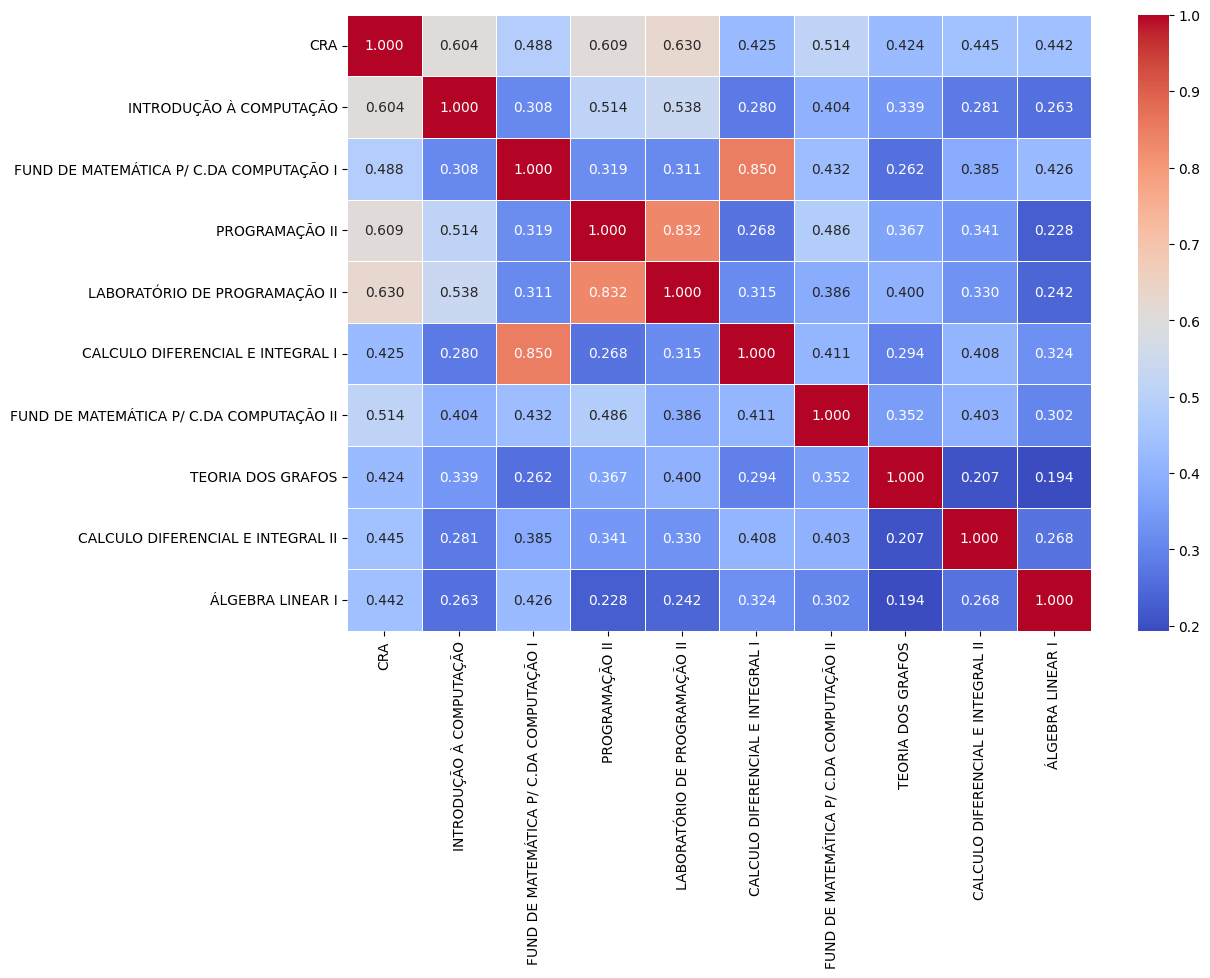

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.show()

In [ ]:
X = pd.DataFrame({
    'intercept': np.ones(df.shape[0]),
    'INTRODUÇÃO À COMPUTAÇÃO': df['INTRODUÇÃO À COMPUTAÇÃO'],
    'FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I': df['FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I'],
    'PROGRAMAÇÃO II': df['PROGRAMAÇÃO II'],
    'LABORATÓRIO DE PROGRAMAÇÃO II': df['LABORATÓRIO DE PROGRAMAÇÃO II'],
    'CALCULO DIFERENCIAL E INTEGRAL I': df['CALCULO DIFERENCIAL E INTEGRAL I'],
    'FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II': df['FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II'],
    'TEORIA DOS GRAFOS': df['TEORIA DOS GRAFOS'],
    'CALCULO DIFERENCIAL E INTEGRAL II': df['CALCULO DIFERENCIAL E INTEGRAL II'],
    'ÁLGEBRA LINEAR I': df['ÁLGEBRA LINEAR I']
})

X[:4]

,intercept,INTRODUÇÃO À COMPUTAÇÃO,FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I,PROGRAMAÇÃO II,LABORATÓRIO DE PROGRAMAÇÃO II,CALCULO DIFERENCIAL E INTEGRAL I,FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II,TEORIA DOS GRAFOS,CALCULO DIFERENCIAL E INTEGRAL II,ÁLGEBRA LINEAR I
0,1.0,6.0,5.7,5.0,6.5,5.7,5.1,7.8,5.0,5.0
1,1.0,7.1,7.5,5.5,5.9,7.5,5.2,5.5,5.0,7.5
2,1.0,8.8,5.6,8.4,7.9,5.6,5.3,8.3,6.1,5.0
3,1.0,7.2,6.0,7.1,7.5,6.0,6.8,7.7,7.5,7.0


In [ ]:
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,1.9480,0.293,6.639,0.000
INTRODUÇÃO À COMPUTAÇÃO,0.1884,0.035,5.433,0.000
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I,0.1013,0.039,2.588,0.010
PROGRAMAÇÃO II,0.0563,0.048,1.177,0.240
LABORATÓRIO DE PROGRAMAÇÃO II,0.1656,0.049,3.347,0.001
CALCULO DIFERENCIAL E INTEGRAL I,-0.0429,0.042,-1.030,0.304
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II,0.0599,0.028,2.101,0.037
TEORIA DOS GRAFOS,0.0681,0.029,2.318,0.021
CALCULO DIFERENCIAL E INTEGRAL II,0.0591,0.020,2.903,0.004
ÁLGEBRA LINEAR I,0.0965,0.025,3.905,0.000


# 4.2 - Como o R2 mudam com a eliminação dessas variáveis?

In [ ]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CRA   R-squared:                       0.628
Model:                            OLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     52.46
Date:                Sat, 14 Dec 2024   Prob (F-statistic):           4.90e-55
Time:                        02:27:21   Log-Likelihood:                -203.69
No. Observations:                 290   AIC:                             427.4
Df Residuals:                     280   BIC:                             464.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
============================================================================================================
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
intercept                                    1.9480      0.293      6.639      0.000       1.370       2.526
INTRODUÇÃO À COMPUTAÇÃO                      0.1884      0.035      5.433      0.000       0.120       0.257
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO I      0.1013      0.039      2.588      0.010       0.024       0.178
PROGRAMAÇÃO II                               0.0563      0.048      1.177      0.240      -0.038       0.151
LABORATÓRIO DE PROGRAMAÇÃO II                0.1656      0.049      3.347      0.001       0.068       0.263
CALCULO DIFERENCIAL E INTEGRAL I            -0.0429      0.042     -1.030      0.304      -0.125       0.039
FUND DE MATEMÁTICA P/ C.DA COMPUTAÇÃO II     0.0599      0.028      2.101      0.037       0.004       0.116
TEORIA DOS GRAFOS                            0.0681      0.029      2.318      0.021       0.010       0.126
CALCULO DIFERENCIAL E INTEGRAL II            0.0591      0.020      2.903      0.004       0.019       0.099
ÁLGEBRA LINEAR I                             0.0965      0.025      3.905      0.000       0.048       0.145
==============================================================================
Omnibus:                       38.799   Durbin-Watson:                   2.190
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.479
Skew:                          -0.815   Prob(JB):                     1.21e-13
Kurtosis:                       4.504   Cond. No.                         229.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

A mudança nos valores de R² e R² ajustado indica uma leve diminuição na explicação da variabilidade dos dados pelo modelo. Embora o R² tenha caído de 0.640 para 0.628, e o R² ajustado de 0.626 para 0.616, isso não afetou significativamente a eficiência do modelo. Ou seja, o modelo ainda explica bem a variabilidade dos dados, mas a redução pode sugerir que ele está agora explicando um pouco menos da variabilidade ou que houve uma leve perda de desempenho. A eficiência, no entanto, permanece consistente.

# 5 - Gere gráficos de resíduos versus valores preditos em cada caso e discuta sobre a presença ou não de padrões sistemáticos.

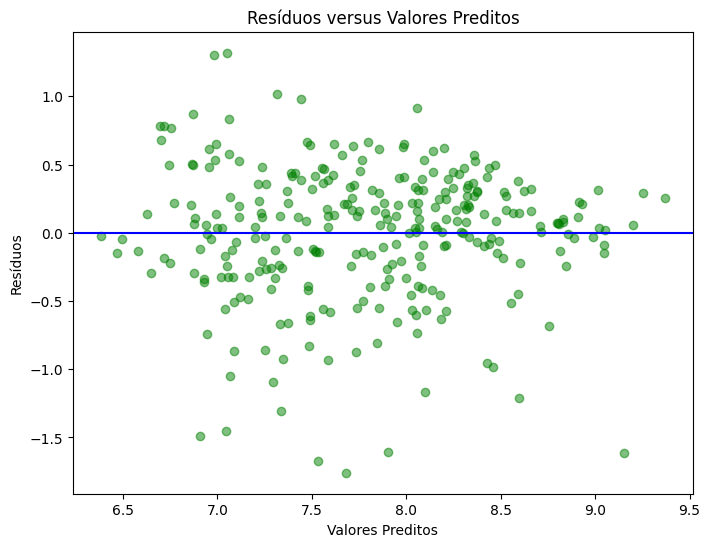

In [ ]:
predictions = results.predict(X)
residuals = y - predictions

plt.figure(figsize=(8, 6))
plt.scatter(predictions, residuals, color='green', alpha=0.5)
plt.axhline(y=0, color='blue', linestyle='-')
plt.title('Resíduos versus Valores Preditos')
plt.xlabel('Valores Preditos')
plt.ylabel('Resíduos')
plt.show()

## Discussão

A partir da análise do gráfico de resíduos, podemos observar que não há um padrão sistemático claro nos resíduos. Eles estão distribuídos de maneira relativamente aleatória em torno de zero, sem indicar um viés perceptível no modelo. A linha de média próxima a zero sugere que não há tendência de subestimação ou superestimação dos valores preditos. Não são observadas evidências significativas de heterocedasticidade ou de uma estrutura de resíduos que sugira um ajuste inadequado do modelo. No entanto, pequenos agrupamentos de pontos podem ser observados em algumas áreas, o que pode indicar que o modelo ainda possui espaço para melhorias em termos de ajuste em determinados intervalos dos valores preditos.